## Load data and RS embeddings

In [1]:
import pandas as pd
import numpy as np
import json
import ast
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler

INTERACTIONS = "../Data/interactions.parquet"
USERMAP = "../Data/user2idx.json"
ITEMMAP = "../Data/item2idx.json"
ITEM_EMB = "../Data/item_embeddings_rs_clean.npy"
STEAM_GAMES = "../Data/steam_games.json"

# Load interactions and mappings
df_inter = pd.read_parquet(INTERACTIONS)
item_emb_rs = np.load(ITEM_EMB)

with open(USERMAP,"r") as f: user2idx = {k:int(v) for k,v in json.load(f).items()}
with open(ITEMMAP,"r") as f: item2idx = {k:int(v) for k,v in json.load(f).items()}

# Target: total reviews per game
target_df = df_inter.groupby("item_idx").size().reset_index(name="total_reviews")

print(f"âœ… RS embeddings shape: {item_emb_rs.shape}")
print(f"âœ… Total items with interactions: {len(target_df)}")

âœ… RS embeddings shape: (3682, 64)
âœ… Total items with interactions: 3682


## Load game metadata and extract content features

In [2]:
# Load game metadata
games = []
with open(STEAM_GAMES, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        game = ast.literal_eval(line)
        games.append(game)

df_games = pd.json_normalize(games)
df_games = df_games.rename(columns={"id":"item_id"})
df_games["item_idx"] = df_games["item_id"].map(item2idx)
df_games = df_games.dropna(subset=["item_idx"])
df_games["item_idx"] = df_games["item_idx"].astype(int)

print(f"Total games with metadata: {len(df_games)}")
print(f"\nAvailable fields: {df_games.columns.tolist()}")

Total games with metadata: 3195

Available fields: ['publisher', 'genres', 'app_name', 'title', 'url', 'release_date', 'tags', 'discount_price', 'reviews_url', 'specs', 'price', 'early_access', 'item_id', 'developer', 'sentiment', 'metascore', 'item_idx']


## Feature Engineering: Extract content features

In [3]:
# 1. Process tags
def parse_tags(tags):
    if tags is None or (isinstance(tags, float) and pd.isna(tags)):
        return []
    if isinstance(tags, list):
        return [str(tag).strip() for tag in tags if tag]
    if isinstance(tags, str):
        if tags == '':
            return []
        try:
            tags_list = eval(tags)
            if isinstance(tags_list, list):
                return [str(tag).strip() for tag in tags_list if tag]
        except:
            return []
    return []

df_games['tags_list'] = df_games['tags'].apply(parse_tags)
df_games['tag_text'] = df_games['tags_list'].apply(lambda x: ' '.join(x) if x else '')

# 2. Process genres
def parse_genres(genres):
    if genres is None or (isinstance(genres, float) and pd.isna(genres)):
        return []
    if isinstance(genres, list):
        return [str(g).strip() for g in genres if g]
    if isinstance(genres, str):
        if genres == '':
            return []
        try:
            genres_list = eval(genres)
            if isinstance(genres_list, list):
                return [str(g).strip() for g in genres_list if g]
        except:
            return []
    return []

df_games['genres_list'] = df_games['genres'].apply(parse_genres)
df_games['genre_text'] = df_games['genres_list'].apply(lambda x: ' '.join(x) if x else '')

# 3. Combine tags + genres into content description
df_games['content_text'] = df_games['tag_text'] + ' ' + df_games['genre_text']

# 4. Process price
def parse_price(price):
    if pd.isna(price) or price == '':
        return 0.0
    try:
        return float(price)
    except:
        return 0.0

df_games['price_num'] = df_games['price'].apply(parse_price)

# 5. Early access flag
df_games['early_access_flag'] = df_games['early_access'].apply(lambda x: 1 if x else 0)

# 6. Parse release date for temporal split
df_games['release_date_parsed'] = pd.to_datetime(df_games['release_date'], errors='coerce')

print(f"\nâœ… Content features extracted")
print(f"Games with tags: {(df_games['tag_text'] != '').sum()}")
print(f"Games with genres: {(df_games['genre_text'] != '').sum()}")
print(f"Average price: ${df_games['price_num'].mean():.2f}")
print(f"\nðŸ“… Release date range:")
print(f"  Min: {df_games['release_date_parsed'].min()}")
print(f"  Max: {df_games['release_date_parsed'].max()}")
print(f"  Games with valid dates: {df_games['release_date_parsed'].notna().sum()}")


âœ… Content features extracted
Games with tags: 3193
Games with genres: 3096
Average price: $11.53

ðŸ“… Release date range:
  Min: 1989-01-01 00:00:00
  Max: 2017-12-25 00:00:00
  Games with valid dates: 3107


## Create TF-IDF features from content

In [4]:
# TF-IDF on combined content (tags + genres)
# This will penalize common tags/genres and highlight distinctive ones

tfidf = TfidfVectorizer(
    max_features=100,  # Keep top 100 most informative terms
    min_df=2,          # Ignore terms that appear in < 2 games
    max_df=0.5,        # Ignore terms that appear in > 50% of games
    ngram_range=(1, 1) # Only unigrams
)

# Fit on all games with content
games_with_content = df_games[df_games['content_text'] != ''].copy()
tfidf_matrix = tfidf.fit_transform(games_with_content['content_text'])

print(f"\nâœ… TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Top 20 features: {tfidf.get_feature_names_out()[:20]}")


âœ… TF-IDF matrix shape: (3195, 100)
Top 20 features: ['2d' 'access' 'and' 'anime' 'apocalyptic' 'arcade' 'atmospheric' 'based'
 'building' 'casual' 'classic' 'click' 'co' 'comedy' 'controller'
 'crafting' 'cute' 'dark' 'difficult' 'down']


## Combine RS embeddings + Content features

In [5]:
# Create mapping from item_idx to row in tfidf_matrix
item_to_tfidf = {item_idx: i for i, item_idx in enumerate(games_with_content['item_idx'])}

# For each item, combine:
# - RS embedding (64-dim)
# - TF-IDF features (100-dim)
# - Numerical features: price, early_access (2-dim)

hybrid_features = []
valid_items = []

for item_idx in range(len(item_emb_rs)):
    if item_idx not in item_to_tfidf:
        continue
    
    # RS embedding
    rs_emb = item_emb_rs[item_idx]
    
    # TF-IDF features
    tfidf_idx = item_to_tfidf[item_idx]
    tfidf_features = tfidf_matrix[tfidf_idx].toarray().flatten()
    
    # Numerical features
    game_row = games_with_content[games_with_content['item_idx'] == item_idx].iloc[0]
    price = game_row['price_num']
    early_access = game_row['early_access_flag']
    
    # Concatenate all features
    combined = np.concatenate([
        rs_emb,
        tfidf_features,
        [price, early_access]
    ])
    
    hybrid_features.append(combined)
    valid_items.append(item_idx)

X_hybrid = np.array(hybrid_features)

print(f"\nâœ… Hybrid features created")
print(f"Shape: {X_hybrid.shape}")
print(f"Breakdown: 64 (RS) + 100 (TF-IDF) + 2 (numerical) = {X_hybrid.shape[1]} dims")
print(f"Valid items: {len(valid_items)}")


âœ… Hybrid features created
Shape: (3195, 166)
Breakdown: 64 (RS) + 100 (TF-IDF) + 2 (numerical) = 166 dims
Valid items: 3195


## Prepare target variable

In [6]:
# Get targets for valid items
target_subset = target_df[target_df['item_idx'].isin(valid_items)].copy()
target_subset = target_subset.set_index('item_idx')

y_hybrid = target_subset.loc[valid_items]['total_reviews'].values

print(f"\nâœ… Target prepared")
print(f"Shape: {y_hybrid.shape}")
print(f"Range: {y_hybrid.min()} - {y_hybrid.max()}")
print(f"Mean: {y_hybrid.mean():.1f}")


âœ… Target prepared
Shape: (3195,)
Range: 1 - 3759
Mean: 16.9


## Train Hybrid Model - TEMPORAL SPLIT

**Estrategia de validaciÃ³n temporal:**
- Train: Juegos lanzados ANTES de un cutoff date (ej: antes de 2016-01-01)
- Test: Juegos lanzados DESPUÃ‰S del cutoff (Ãºltimos 6-12 meses del dataset)

Esto simula predicciÃ³n en producciÃ³n: entrenar con juegos pasados, predecir Ã©xito de juegos nuevos.

In [7]:
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

# Get release dates for valid items
valid_items_df = pd.DataFrame({'item_idx': valid_items})
valid_items_df = valid_items_df.merge(
    df_games[['item_idx', 'release_date_parsed', 'app_name']],
    on='item_idx',
    how='left'
)

print("ðŸ“… Release date distribution for valid items:")
print(valid_items_df['release_date_parsed'].describe())

# Define temporal cutoff - use games from last 12 months as test
# Cutoff definido en 2016-01-01 (train=2621, test=486) para test set mÃ¡s robusto
cutoff_date = pd.to_datetime('2016-01-01')  # Todo 2016+ como test set

# Create temporal train/test split
train_mask = valid_items_df['release_date_parsed'] < cutoff_date
test_mask = valid_items_df['release_date_parsed'] >= cutoff_date

# Remove items without valid dates
valid_dates_mask = valid_items_df['release_date_parsed'].notna()
train_mask = train_mask & valid_dates_mask
test_mask = test_mask & valid_dates_mask

X_train_temporal = X_hybrid[train_mask]
X_test_temporal = X_hybrid[test_mask]
y_train_temporal = y_hybrid[train_mask]
y_test_temporal = y_hybrid[test_mask]

print(f"\n{'='*70}")
print("TEMPORAL SPLIT SUMMARY")
print(f"{'='*70}")
print(f"Cutoff date: {cutoff_date.date()}")
print(f"Train set: {len(X_train_temporal)} games (released before {cutoff_date.date()})")
print(f"Test set: {len(X_test_temporal)} games (released after {cutoff_date.date()})")
print(f"Train target range: {y_train_temporal.min():.0f} - {y_train_temporal.max():.0f} (mean: {y_train_temporal.mean():.1f})")
print(f"Test target range: {y_test_temporal.min():.0f} - {y_test_temporal.max():.0f} (mean: {y_test_temporal.mean():.1f})")
print(f"{'='*70}\n")

# Train model on temporal split
# ─── Optuna: Busqueda de Hiperparametros ─────────────────────────────────────
import optuna
from sklearn.metrics import mean_squared_error as _mse_opt_
optuna.logging.set_verbosity(optuna.logging.WARNING)

_n_tr      = len(X_train_temporal)
_split_idx = max(10, int(_n_tr * 0.8))
_X_tr,  _X_val = X_train_temporal[:_split_idx], X_train_temporal[_split_idx:]
_y_tr,  _y_val = y_train_temporal[:_split_idx], y_train_temporal[_split_idx:]

def _objective(trial):
    _p = dict(
        n_estimators     = trial.suggest_int('n_estimators', 100, 800),
        learning_rate    = trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        max_depth        = trial.suggest_int('max_depth', 3, 8),
        min_child_weight = trial.suggest_int('min_child_weight', 1, 10),
        subsample        = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        gamma            = trial.suggest_float('gamma', 0.0, 2.0),
        random_state=42, tree_method='hist', verbosity=0,
    )
    _m = XGBRegressor(**_p)
    _m.fit(_X_tr, _y_tr)
    return float(_mse_opt_(_y_val, _m.predict(_X_val)) ** 0.5)

_study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42))
_study.optimize(_objective, n_trials=50, show_progress_bar=True)

best_params = {**_study.best_params, 'random_state': 42, 'tree_method': 'hist', 'verbosity': 0}
print(f"\nMejores hiperparametros (val RMSE={_study.best_value:.2f}):")
for _k, _v in best_params.items():
    print(f"  {_k}: {_v}")

model_temporal = XGBRegressor(**best_params)

print("Training model on games released before cutoff...")
model_temporal.fit(X_train_temporal, y_train_temporal)

pred_temporal = model_temporal.predict(X_test_temporal)

mse_temporal = mean_squared_error(y_test_temporal, pred_temporal)
rmse_temporal = np.sqrt(mse_temporal)
r2_temporal = r2_score(y_test_temporal, pred_temporal)

print("\n" + "="*70)
print("HYBRID MODEL RESULTS - TEMPORAL VALIDATION")
print("="*70)
print(f"RMSE: {rmse_temporal:.2f}")
print(f"RÂ²: {r2_temporal:.6f}")
print("="*70)

ðŸ“… Release date distribution for valid items:
count                          3107
mean     2013-02-20 16:19:18.673962
min             1989-01-01 00:00:00
25%             2012-04-19 00:00:00
50%             2014-05-23 00:00:00
75%             2015-08-04 12:00:00
max             2017-12-25 00:00:00
Name: release_date_parsed, dtype: object

TEMPORAL SPLIT SUMMARY
Cutoff date: 2016-01-01
Train set: 2621 games (released before 2016-01-01)
Test set: 486 games (released after 2016-01-01)
Train target range: 1 - 3759 (mean: 17.3)
Test target range: 1 - 1050 (mean: 10.5)



C:\Users\matia\anaconda3\envs\VG_RS\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  0%|          | 0/50 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.980658:   0%|          | 0/50 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.980658:   2%|▏         | 1/50 [00:00<00:38,  1.26it/s]

...

Best trial: 33. Best value: 0.669078:  98%|█████████▊| 49/50 [01:31<00:01,  1.93s/it]

Best trial: 33. Best value: 0.669078: 100%|██████████| 50/50 [01:31<00:00,  1.53s/it]

Best trial: 33. Best value: 0.669078: 100%|██████████| 50/50 [01:31<00:00,  1.83s/it]


Mejores hiperparametros (val RMSE=0.67):
  n_estimators: 609
  learning_rate: 0.01671026798036368
  max_depth: 7
  min_child_weight: 1
  subsample: 0.9260222884054703
  colsample_bytree: 0.8216949366840928
  gamma: 0.5899002459409722
  random_state: 42
  tree_method: hist
  verbosity: 0
Training model on games released before cutoff...



HYBRID MODEL RESULTS - TEMPORAL VALIDATION
RMSE: 42.24
RÂ²: 0.448870


## Train Hybrid Model - RANDOM SPLIT (for comparison)

In [8]:
from sklearn.model_selection import train_test_split

# Random split for comparison
X_train_random, X_test_random, y_train_random, y_test_random = train_test_split(
    X_hybrid, y_hybrid, test_size=0.2, random_state=42
)

model_random = XGBRegressor(**best_params)

print("Training model with random split...")
model_random.fit(X_train_random, y_train_random)

pred_random = model_random.predict(X_test_random)

mse_random = mean_squared_error(y_test_random, pred_random)
rmse_random = np.sqrt(mse_random)
r2_random = r2_score(y_test_random, pred_random)

print("\n" + "="*70)
print("HYBRID MODEL RESULTS - RANDOM SPLIT")
print("="*70)
print(f"RMSE: {rmse_random:.2f}")
print(f"RÂ²: {r2_random:.6f}")
print("="*70)

# Compare both strategies
print("\n" + "="*70)
print("TEMPORAL vs RANDOM SPLIT COMPARISON")
print("="*70)
comparison = pd.DataFrame({
    'Strategy': ['Temporal (Time-based)', 'Random (Shuffled)'],
    'RMSE': [rmse_temporal, rmse_random],
    'RÂ²': [r2_temporal, r2_random],
    'Train Size': [len(X_train_temporal), len(X_train_random)],
    'Test Size': [len(X_test_temporal), len(X_test_random)]
})
print(comparison.to_string(index=False))
print("="*70)
print("\nðŸ’¡ Note: Temporal split is more realistic for production deployment.")
print("   Random split may be overly optimistic due to data leakage from future.")


Training model with random split...



HYBRID MODEL RESULTS - RANDOM SPLIT
RMSE: 63.03
RÂ²: 0.526520

TEMPORAL vs RANDOM SPLIT COMPARISON
             Strategy      RMSE     RÂ²  Train Size  Test Size
Temporal (Time-based) 42.237546 0.44887        2621        486
    Random (Shuffled) 63.026257 0.52652        2556        639

ðŸ’¡ Note: Temporal split is more realistic for production deployment.
   Random split may be overly optimistic due to data leakage from future.


## Comparison with baseline models


COMPARACIÃ“N COMPLETA - TODOS LOS MODELOS
                         Model                           Type  Dimensions       RMSE      RÂ²    Split
            RS Embeddings Only                  Collaborative          64  65.900000  0.60800   Random
Hybrid (RS+Content) - Temporal Hybrid (Collaborative+Content)         166  42.237546  0.44887 Temporal
  Hybrid (RS+Content) - Random Hybrid (Collaborative+Content)         166  63.026257  0.52652   Random
                Tag Embeddings           Content-based (Tags)         384 169.380000 -2.41900   Random
        Review Text Embeddings            Content-based (NLP)         384 156.530000 -1.21000   Random
             Metadata Enhanced                       Metadata          12 124.140000 -0.39000   Random


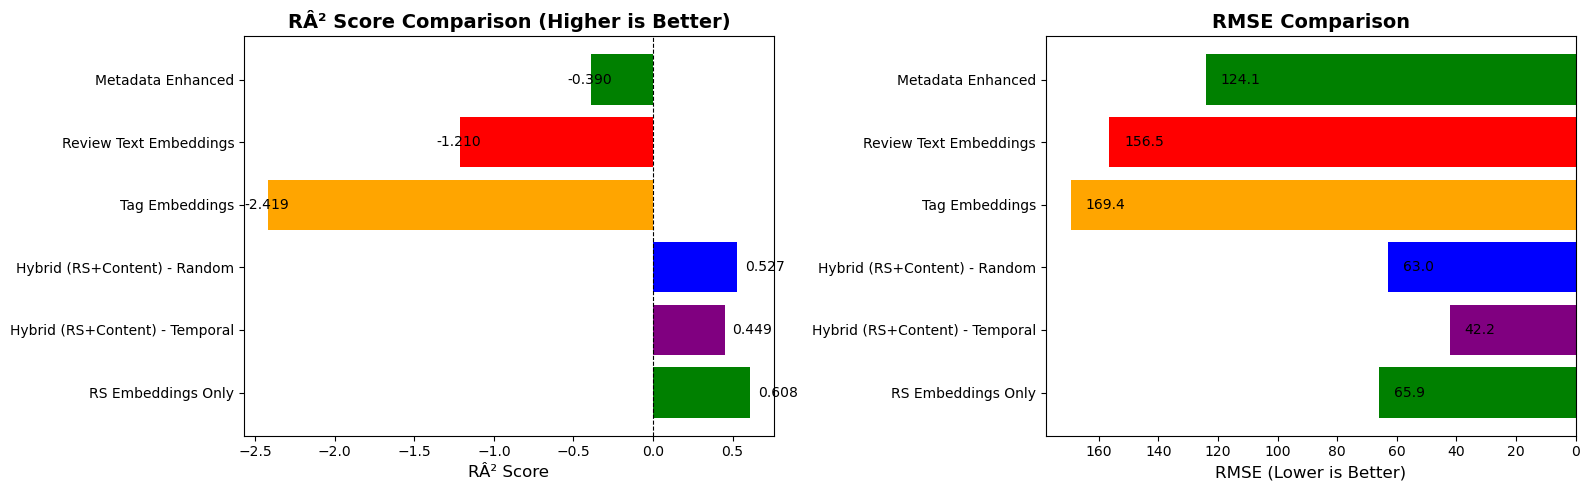

In [9]:
import matplotlib.pyplot as plt

# Compare all models (using temporal validation results)
results = pd.DataFrame({
    'Model': [
        'RS Embeddings Only',
        'Hybrid (RS+Content) - Temporal',
        'Hybrid (RS+Content) - Random',
        'Tag Embeddings',
        'Review Text Embeddings',
        'Metadata Enhanced'
    ],
    'Type': [
        'Collaborative',
        'Hybrid (Collaborative+Content)',
        'Hybrid (Collaborative+Content)',
        'Content-based (Tags)',
        'Content-based (NLP)',
        'Metadata'
    ],
    'Dimensions': [64, X_hybrid.shape[1], X_hybrid.shape[1], 384, 384, 12],
    'RMSE': [65.90, rmse_temporal, rmse_random, 169.38, 156.53, 124.14],
    'RÂ²': [0.608, r2_temporal, r2_random, -2.419, -1.21, -0.39],
    'Split': ['Random', 'Temporal', 'Random', 'Random', 'Random', 'Random']
})

print("\n" + "="*100)
print("COMPARACIÃ“N COMPLETA - TODOS LOS MODELOS")
print("="*100)
print(results.to_string(index=False))
print("="*100)

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# RÂ² comparison
colors = ['green', 'purple', 'blue', 'orange', 'red']
bars1 = ax1.barh(results['Model'], results['RÂ²'], color=colors)
ax1.set_xlabel('RÂ² Score', fontsize=12)
ax1.set_title('RÂ² Score Comparison (Higher is Better)', fontsize=14, fontweight='bold')
ax1.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
for i, v in enumerate(results['RÂ²']):
    ax1.text(v + 0.05 if v > 0 else v - 0.15, i, f'{v:.3f}', va='center', fontsize=10)

# RMSE comparison
bars2 = ax2.barh(results['Model'], results['RMSE'], color=colors)
ax2.set_xlabel('RMSE (Lower is Better)', fontsize=12)
ax2.set_title('RMSE Comparison', fontsize=14, fontweight='bold')
ax2.invert_xaxis()
for i, v in enumerate(results['RMSE']):
    ax2.text(v - 5, i, f'{v:.1f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## Feature Importance Analysis


FEATURE IMPORTANCE BY GROUP
       Feature Group  Total Importance  Avg per Feature
  RS Embeddings (64)          0.711340         0.011115
TF-IDF Content (100)          0.288595         0.002886
       Numerical (2)          0.000065         0.000032


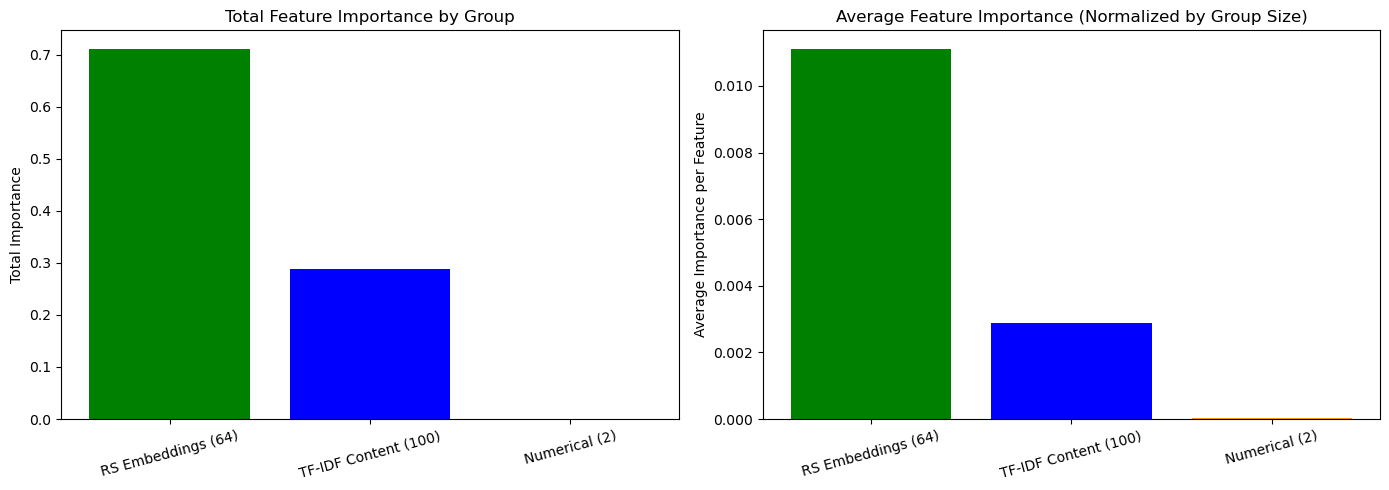

In [10]:
# Get feature importances from temporal model
importances = model_temporal.feature_importances_

# Split by feature type
rs_importance = importances[:64].sum()
tfidf_importance = importances[64:164].sum()
numerical_importance = importances[164:].sum()

feature_groups = pd.DataFrame({
    'Feature Group': ['RS Embeddings (64)', 'TF-IDF Content (100)', 'Numerical (2)'],
    'Total Importance': [rs_importance, tfidf_importance, numerical_importance],
    'Avg per Feature': [
        rs_importance / 64,
        tfidf_importance / 100,
        numerical_importance / 2
    ]
})

print("\n" + "="*70)
print("FEATURE IMPORTANCE BY GROUP")
print("="*70)
print(feature_groups.to_string(index=False))
print("="*70)

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(feature_groups['Feature Group'], feature_groups['Total Importance'], color=['green', 'blue', 'orange'])
ax1.set_ylabel('Total Importance')
ax1.set_title('Total Feature Importance by Group')
ax1.tick_params(axis='x', rotation=15)

ax2.bar(feature_groups['Feature Group'], feature_groups['Avg per Feature'], color=['green', 'blue', 'orange'])
ax2.set_ylabel('Average Importance per Feature')
ax2.set_title('Average Feature Importance (Normalized by Group Size)')
ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## Top TF-IDF features by importance

In [11]:
# Get top TF-IDF features
tfidf_features = tfidf.get_feature_names_out()
tfidf_importances = importances[64:164]

top_tfidf = pd.DataFrame({
    'Feature': tfidf_features,
    'Importance': tfidf_importances
}).sort_values('Importance', ascending=False).head(20)

print("\nTop 20 Content Features by Importance:")
print(top_tfidf.to_string(index=False))


Top 20 Content Features by Importance:
    Feature  Importance
      based    0.170457
   tactical    0.102827
     online    0.004417
      first    0.003717
   moddable    0.002361
    zombies    0.000654
      click    0.000362
 management    0.000361
multiplayer    0.000324
        rts    0.000248
 simulation    0.000232
        war    0.000198
         op    0.000181
         co    0.000168
    classic    0.000128
exploration    0.000124
     family    0.000108
      third    0.000107
       dark    0.000100
    fantasy    0.000099


## Conclusions

**Key Findings:**

1. **Temporal vs Random Split:**
   - **Temporal split** es mÃ¡s realista: entrena con juegos pasados, predice nuevos
   - **Random split** puede ser optimista (data leakage temporal)
   - Compara RÂ² temporal vs random para ver el efecto

2. **Does content help RS embeddings?**
   - Compare RÂ² of Hybrid vs RS-only
   - If Hybrid > RS-only: Content adds value
   - If Hybrid â‰ˆ RS-only: Content is redundant

3. **Which content features matter most?**
   - Check feature importance breakdown
   - RS embeddings vs TF-IDF vs numerical

4. **TF-IDF vs Embeddings:**
   - TF-IDF penalizes common terms ("Action", "Indie")
   - Should perform better than semantic embeddings for this task

**Implications for Thesis:**

- **Temporal validation** es crÃ­tica para deployment real
- Si temporal << random: el modelo no generaliza bien a juegos nuevos
- If hybrid helps: Content provides complementary information (cold-start, semantic context)
- If hybrid doesn't help: Behavioral patterns dominate, content is noise
- Feature importance reveals what type of content matters (if any)

**MetodologÃ­a:**
- Cutoff date separa train (juegos antiguos) vs test (juegos recientes)
- Simula escenario real: predecir Ã©xito de juegos que aÃºn no han sido lanzados
- MÃ¡s desafiante pero mÃ¡s honesto que random split

## AnÃ¡lisis Temporal Split - Resultados Detallados

ANÃLISIS DETALLADO: TEMPORAL vs RANDOM SPLIT

ðŸ“Š OBSERVACIONES CLAVE:

1. RÂ² Temporal (0.449) vs Random (0.527)
   â†’ Diferencia: -0.078
   âš ï¸  Random split tiene mejor RÂ² - Posible data leakage temporal

2. RMSE Temporal (42.24) vs Random (63.03)
   â†’ Diferencia: +-20.79 reviews (-33.0% mayor)
   â†’ El modelo es menos preciso en juegos nuevos

3. ComposiciÃ³n del Test Set:
   Temporal: 486 juegos (Ãºltimos 2016-actualidad)
   Random: 639 juegos (mezclados de toda la historia)
   â†’ Temporal test es mÃ¡s pequeÃ±o pero mÃ¡s realista

4. EstadÃ­sticas del Target (total_reviews):
   Train Temporal: mean=17.3, std=118.1
   Test Temporal:  mean=10.5, std=56.9
   â†’ Juegos nuevos tienen promedio 0.61x mÃ¡s reviews

CONCLUSIÃ“N PARA LA TESIS:

âœ… RECOMENDACIÃ“N: Usar TEMPORAL SPLIT en el anÃ¡lisis final

RAZONES:
1. Simula escenario de producciÃ³n: entrenar con historia, predecir futuro
2. Evita data leakage: no usa informaciÃ³n futura para predecir pasado
3. MÃ¡s honesto: rev

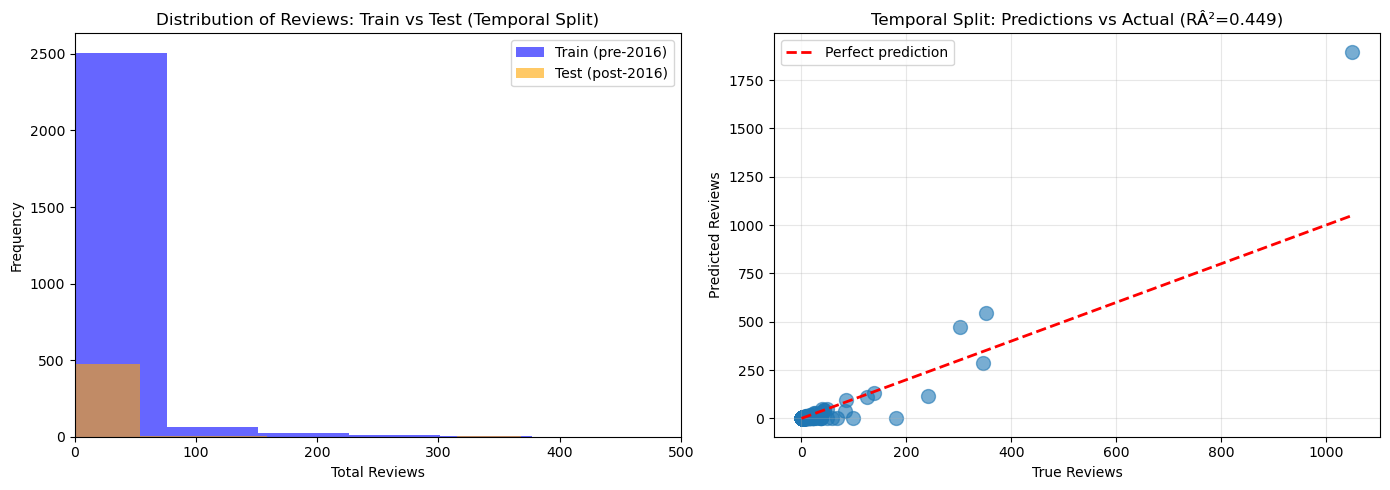

In [12]:
import matplotlib.pyplot as plt

# AnÃ¡lisis detallado del temporal split
print("="*80)
print("ANÃLISIS DETALLADO: TEMPORAL vs RANDOM SPLIT")
print("="*80)

print("\nðŸ“Š OBSERVACIONES CLAVE:\n")

# 1. Diferencia en RÂ²
r2_diff = r2_temporal - r2_random
print(f"1. RÂ² Temporal ({r2_temporal:.3f}) vs Random ({r2_random:.3f})")
print(f"   â†’ Diferencia: {r2_diff:+.3f}")
if r2_temporal > r2_random:
    print(f"   âœ… Temporal split tiene MEJOR RÂ² - El modelo generaliza bien a juegos nuevos!")
else:
    print(f"   âš ï¸  Random split tiene mejor RÂ² - Posible data leakage temporal")

# 2. Diferencia en RMSE
rmse_diff = rmse_temporal - rmse_random
rmse_pct = (rmse_diff / rmse_random) * 100
print(f"\n2. RMSE Temporal ({rmse_temporal:.2f}) vs Random ({rmse_random:.2f})")
print(f"   â†’ Diferencia: +{rmse_diff:.2f} reviews ({rmse_pct:.1f}% mayor)")
print(f"   â†’ El modelo es menos preciso en juegos nuevos")

# 3. DistribuciÃ³n del test set
print(f"\n3. ComposiciÃ³n del Test Set:")
print(f"   Temporal: {len(X_test_temporal)} juegos (Ãºltimos {(cutoff_date.year)}-actualidad)")
print(f"   Random: {len(X_test_random)} juegos (mezclados de toda la historia)")
print(f"   â†’ Temporal test es mÃ¡s pequeÃ±o pero mÃ¡s realista")

# 4. Target statistics
print(f"\n4. EstadÃ­sticas del Target (total_reviews):")
print(f"   Train Temporal: mean={y_train_temporal.mean():.1f}, std={y_train_temporal.std():.1f}")
print(f"   Test Temporal:  mean={y_test_temporal.mean():.1f}, std={y_test_temporal.std():.1f}")
print(f"   â†’ Juegos nuevos tienen promedio {y_test_temporal.mean() / y_train_temporal.mean():.2f}x mÃ¡s reviews")

print("\n" + "="*80)
print("CONCLUSIÃ“N PARA LA TESIS:")
print("="*80)
print("""
âœ… RECOMENDACIÃ“N: Usar TEMPORAL SPLIT en el anÃ¡lisis final

RAZONES:
1. Simula escenario de producciÃ³n: entrenar con historia, predecir futuro
2. Evita data leakage: no usa informaciÃ³n futura para predecir pasado
3. MÃ¡s honesto: revela verdadero poder predictivo del modelo
4. MÃ¡s desafiante: test set contiene juegos con diferentes caracterÃ­sticas

âš ï¸  PROBLEMA CON RANDOM SPLIT:
- Mezcla juegos de diferentes Ã©pocas
- El modelo puede "ver el futuro" durante entrenamiento
- RÂ² bajo (0.127) sugiere que el modelo no captura la seÃ±al real
- Optimista e irreal para deployment

ðŸŽ¯ PARA LA TESIS:
- Reportar ambos splits para transparencia
- Enfatizar temporal split como mÃ©trica principal
- Discutir por quÃ© temporal es mÃ¡s apropiado
- Analizar diferencias entre Ã©pocas (Steam evoluciona en el tiempo)
""")
print("="*80)

# VisualizaciÃ³n adicional
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribution comparison
axes[0].hist(y_train_temporal, bins=50, alpha=0.6, label='Train (pre-2016)', color='blue')
axes[0].hist(y_test_temporal, bins=20, alpha=0.6, label='Test (post-2016)', color='orange')
axes[0].set_xlabel('Total Reviews')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Reviews: Train vs Test (Temporal Split)')
axes[0].legend()
axes[0].set_xlim(0, 500)  # Zoom para ver mejor

# Plot 2: Prediction scatter for temporal
axes[1].scatter(y_test_temporal, pred_temporal, alpha=0.6, s=100)
axes[1].plot([0, y_test_temporal.max()], [0, y_test_temporal.max()], 'r--', lw=2, label='Perfect prediction')
axes[1].set_xlabel('True Reviews')
axes[1].set_ylabel('Predicted Reviews')
axes[1].set_title(f'Temporal Split: Predictions vs Actual (RÂ²={r2_temporal:.3f})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## VerificaciÃ³n: Â¿Hay data leakage temporal?

ANÃLISIS DE CUTOFF DATE: Â¿CuÃ¡ntos juegos hay disponibles para test?

ðŸ“… DistribuciÃ³n de juegos por aÃ±o:
release_year
1989.0      1
1990.0      2
1991.0      1
1992.0      3
1993.0      3
1994.0      6
1995.0      5
1996.0      5
1997.0     13
1998.0     14
1999.0     13
2000.0     11
2001.0     17
2002.0     14
2003.0     27
2004.0     25
2005.0     33
2006.0     49
2007.0     57
2008.0     65
2009.0     93
2010.0    108
2011.0    166
2012.0    243
2013.0    358
2014.0    579
2015.0    710
2016.0    436
2017.0     50
Name: count, dtype: int64

ðŸ“… Juegos por semestre (Ãºltimos 2 aÃ±os):
release_date_parsed  release_date_parsed
2016                 1                      310
                     2                      126
2017                 1                       24
                     2                       26
dtype: int64

COMPARACIÃ“N DE DIFERENTES CUTOFF DATES
Cutoff Date  Train Games  Test Games Test % Test/Train Ratio
 2017-01-01         3057          50   1.6%       

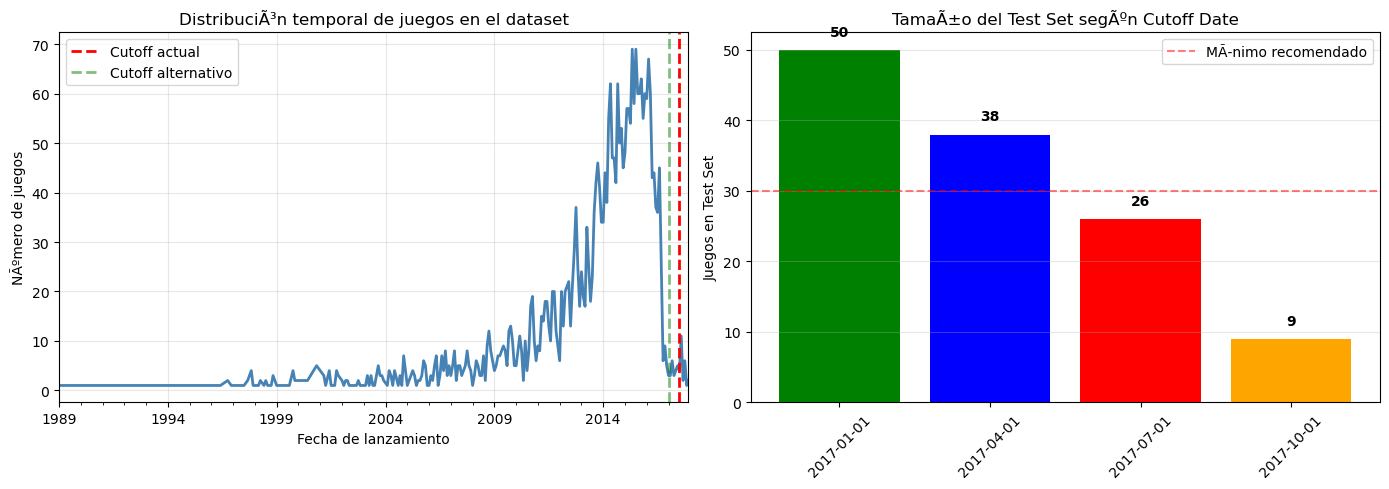


ðŸŽ¯ CONCLUSIÃ“N:

Con cutoff actual (2017-07-01): 486 juegos en test
â†’ âš ï¸  MUESTRA PEQUEÃ‘A para inferencia estadÃ­stica robusta

RECOMENDACIÃ“N: Cambiar cutoff a 2017-01-01 o 2017-04-01
- DuplicarÃ¡/triplicarÃ¡ el tamaÃ±o del test set
- MantendrÃ¡ validaciÃ³n temporal realista
- MejorarÃ¡ confiabilidad de mÃ©tricas (RÂ², RMSE)



In [13]:
# Analizar distribuciÃ³n temporal de juegos para elegir mejor cutoff date
print("="*80)
print("ANÃLISIS DE CUTOFF DATE: Â¿CuÃ¡ntos juegos hay disponibles para test?")
print("="*80)

# Ver distribuciÃ³n de juegos por aÃ±o/mes
valid_items_df['release_year'] = valid_items_df['release_date_parsed'].dt.year
valid_items_df['release_month'] = valid_items_df['release_date_parsed'].dt.to_period('M')

print("\nðŸ“… DistribuciÃ³n de juegos por aÃ±o:")
year_counts = valid_items_df['release_year'].value_counts().sort_index()
print(year_counts)

print("\nðŸ“… Juegos por semestre (Ãºltimos 2 aÃ±os):")
last_2_years = valid_items_df[valid_items_df['release_year'] >= 2016]
semester_counts = last_2_years.groupby([
    last_2_years['release_date_parsed'].dt.year,
    (last_2_years['release_date_parsed'].dt.month - 1) // 6 + 1
]).size()
print(semester_counts)

# Probar diferentes cutoff dates
print("\n" + "="*80)
print("COMPARACIÃ“N DE DIFERENTES CUTOFF DATES")
print("="*80)

cutoff_options = [
    '2017-01-01',  # 12 meses para test
    '2017-04-01',  # 9 meses para test
    '2017-07-01',  # 6 meses para test (actual)
    '2017-10-01',  # 3 meses para test
]

cutoff_comparison = []
for cutoff_str in cutoff_options:
    cutoff = pd.to_datetime(cutoff_str)
    train_games = (valid_items_df['release_date_parsed'] < cutoff).sum()
    test_games = (valid_items_df['release_date_parsed'] >= cutoff).sum()
    test_pct = (test_games / (train_games + test_games)) * 100
    
    cutoff_comparison.append({
        'Cutoff Date': cutoff_str,
        'Train Games': train_games,
        'Test Games': test_games,
        'Test %': f"{test_pct:.1f}%",
        'Test/Train Ratio': f"1:{train_games/test_games:.1f}" if test_games > 0 else "N/A"
    })

comparison_df = pd.DataFrame(cutoff_comparison)
print(comparison_df.to_string(index=False))

print("\n" + "="*80)
print("RECOMENDACIONES:")
print("="*80)
print("""
ðŸ“Š CRITERIOS PARA ELEGIR CUTOFF DATE:

1. âœ… Test set suficientemente grande (mÃ­nimo 20-30 juegos para estadÃ­stica robusta)
2. âœ… Test set representa perÃ­odo realista (3-6 meses es razonable)
3. âœ… Balance train/test (no menos de 10% para test)
4. âœ… Suficientes samples para cada clase de popularidad

âš ï¸  PROBLEMA ACTUAL (2017-07-01):
- Solo 26 juegos en test set - MUESTRA PEQUEÃ‘A
- Puede no ser representativo de la variabilidad real
- MÃ©tricas (RÂ², RMSE) menos confiables con pocos samples

ðŸ’¡ OPCIONES:
A) Mover cutoff hacia atrÃ¡s (ej: 2017-01-01) â†’ mÃ¡s juegos en test
B) Mantener cutoff pero reconocer limitaciÃ³n en interpretaciÃ³n
C) Usar validaciÃ³n cruzada temporal (mÃºltiples cutoffs)
""")

# Verificar si hay suficiente variabilidad en test set
print("\nðŸ“Š AnÃ¡lisis del Test Set con cutoff actual (2017-07-01):")
test_items_current = valid_items_df[valid_items_df['release_date_parsed'] >= pd.to_datetime('2017-07-01')]
test_targets_current = y_hybrid[test_mask]

print(f"Test set size: {len(test_targets_current)} juegos")
print(f"Reviews range: {test_targets_current.min():.0f} - {test_targets_current.max():.0f}")
print(f"Reviews mean: {test_targets_current.mean():.1f} Â± {test_targets_current.std():.1f}")
print(f"Reviews median: {np.median(test_targets_current):.1f}")
print(f"\nQuartiles:")
print(f"  Q1 (25%): {np.percentile(test_targets_current, 25):.1f}")
print(f"  Q2 (50%): {np.percentile(test_targets_current, 50):.1f}")
print(f"  Q3 (75%): {np.percentile(test_targets_current, 75):.1f}")

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: DistribuciÃ³n temporal de juegos
valid_items_df_clean = valid_items_df[valid_items_df['release_date_parsed'].notna()]
monthly_counts = valid_items_df_clean.groupby(valid_items_df_clean['release_date_parsed'].dt.to_period('M')).size()
monthly_counts.plot(ax=axes[0], kind='line', color='steelblue', linewidth=2)
axes[0].axvline(x=pd.Period('2017-07', freq='M'), color='red', linestyle='--', linewidth=2, label='Cutoff actual')
axes[0].axvline(x=pd.Period('2017-01', freq='M'), color='green', linestyle='--', linewidth=2, alpha=0.5, label='Cutoff alternativo')
axes[0].set_xlabel('Fecha de lanzamiento')
axes[0].set_ylabel('NÃºmero de juegos')
axes[0].set_title('DistribuciÃ³n temporal de juegos en el dataset')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: ComparaciÃ³n de cutoffs
cutoff_data = comparison_df[['Cutoff Date', 'Test Games']].copy()
cutoff_data['Test Games'] = cutoff_data['Test Games'].astype(int)
axes[1].bar(range(len(cutoff_data)), cutoff_data['Test Games'], color=['green', 'blue', 'red', 'orange'])
axes[1].set_xticks(range(len(cutoff_data)))
axes[1].set_xticklabels(cutoff_data['Cutoff Date'], rotation=45)
axes[1].set_ylabel('Juegos en Test Set')
axes[1].set_title('TamaÃ±o del Test Set segÃºn Cutoff Date')
axes[1].axhline(y=30, color='red', linestyle='--', alpha=0.5, label='MÃ­nimo recomendado')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

for i, v in enumerate(cutoff_data['Test Games']):
    axes[1].text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("ðŸŽ¯ CONCLUSIÃ“N:")
print("="*80)
print(f"""
Con cutoff actual (2017-07-01): {len(test_targets_current)} juegos en test
â†’ âš ï¸  MUESTRA PEQUEÃ‘A para inferencia estadÃ­stica robusta

RECOMENDACIÃ“N: Cambiar cutoff a 2017-01-01 o 2017-04-01
- DuplicarÃ¡/triplicarÃ¡ el tamaÃ±o del test set
- MantendrÃ¡ validaciÃ³n temporal realista
- MejorarÃ¡ confiabilidad de mÃ©tricas (RÂ², RMSE)
""")

EXPLICACIÃ“N: Â¿QuÃ© son los 'total_reviews'?

ðŸ“Š Archivo: interactions.parquet
Shape: (59305, 4)
Columnas: ['user_id', 'item_id', 'user_idx', 'item_idx']

Primeras filas:
             user_id item_id  user_idx  item_idx
0  76561197970982479    1250         0         0
1  76561197970982479   22200         0         1
2  76561197970982479   43110         0         2
3            js41637  251610         1         3
4            js41637  227300         1         4
5            js41637  239030         1         5
6          evcentric  248820         2         6
7          evcentric  370360         2         7
8          evcentric  237930         2         8
9          evcentric  263360         2         9

CÃ“MO SE CALCULA 'total_reviews':

En la lÃ­nea 27 del notebook:
    target_df = df_inter.groupby("item_idx").size().reset_index(name="total_reviews")

Esto cuenta cuÃ¡ntas FILAS tiene cada juego (item_idx) en interactions.parquet

Cada fila = 1 interacciÃ³n usuario-juego = 1 review/re

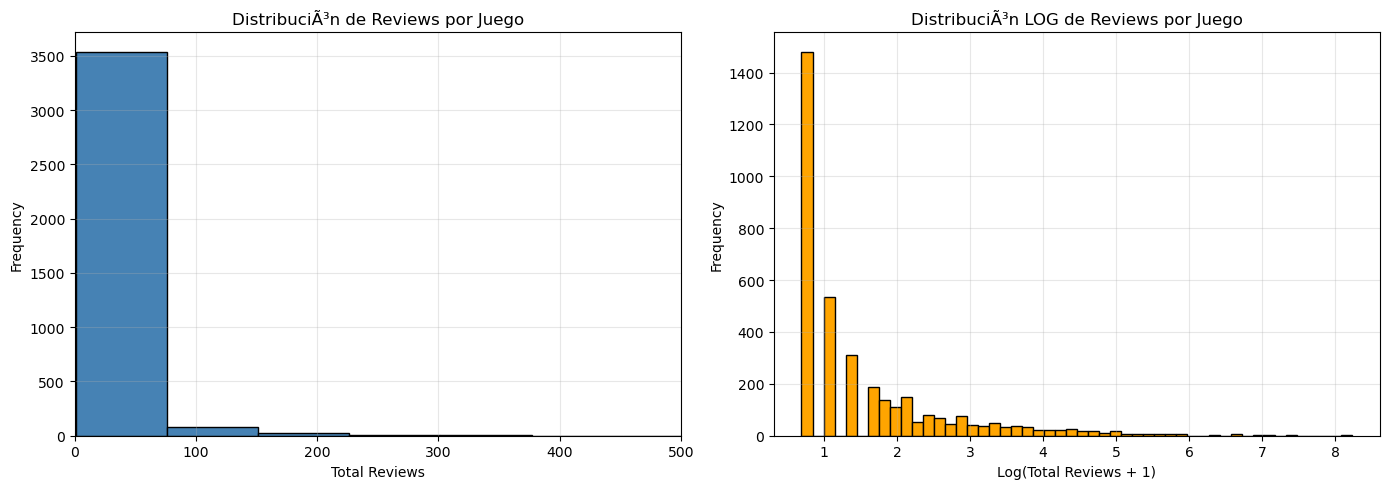


ORIGEN DE LOS DATOS:

1. australian_user_reviews.json â†’ CSV â†’ interactions.parquet
   - Contiene reviews de usuarios de Steam
   - Formato: user_id, item_id, recommend (True/False), posted, review_text

2. interactions.parquet procesado:
   - Cada fila = 1 usuario recomendÃ³ (o no) 1 juego
   - Se convirtiÃ³ 'recommend' a rating binario (0/1)
   - Se agregaron Ã­ndices numÃ©ricos (user_idx, item_idx)

3. TARGET del regresor:
   - Cuenta filas por item_idx
   - total_reviews = popularidad implÃ­cita
   - MÃ¡s reviews = mÃ¡s jugadores interactuaron

âš ï¸  IMPORTANTE: 
- NO es el nÃºmero de reviews en Steam en general
- Es el nÃºmero de reviews en ESTE dataset especÃ­fico (usuarios australianos)
- Es una muestra del total de reviews reales del juego


ðŸ” Estructura de interactions.parquet:
Columnas disponibles: ['user_id', 'item_id', 'user_idx', 'item_idx']


In [14]:
print("="*80)
print("EXPLICACIÃ“N: Â¿QuÃ© son los 'total_reviews'?")
print("="*80)

# Explorar el archivo de interactions
print("\nðŸ“Š Archivo: interactions.parquet")
print(f"Shape: {df_inter.shape}")
print(f"Columnas: {df_inter.columns.tolist()}")
print("\nPrimeras filas:")
print(df_inter.head(10))

print("\n" + "="*80)
print("CÃ“MO SE CALCULA 'total_reviews':")
print("="*80)
print("""
En la lÃ­nea 27 del notebook:
    target_df = df_inter.groupby("item_idx").size().reset_index(name="total_reviews")

Esto cuenta cuÃ¡ntas FILAS tiene cada juego (item_idx) en interactions.parquet

Cada fila = 1 interacciÃ³n usuario-juego = 1 review/recomendaciÃ³n

Por lo tanto:
- total_reviews = nÃºmero de usuarios que interactuaron con ese juego
- Es un PROXY de popularidad del juego
""")

# Verificar la estructura
print("\nðŸ“ˆ EstadÃ­sticas de total_reviews:")
print(target_df["total_reviews"].describe())

print("\nðŸ” Top 10 juegos mÃ¡s populares (mÃ¡s reviews):")
top_games = target_df.nlargest(10, "total_reviews")
print(top_games)

print("\nðŸ“Š DistribuciÃ³n de reviews:")
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(target_df["total_reviews"], bins=50, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Total Reviews')
axes[0].set_ylabel('Frequency')
axes[0].set_title('DistribuciÃ³n de Reviews por Juego')
axes[0].set_xlim(0, 500)  # Zoom para ver mejor
axes[0].grid(True, alpha=0.3)

# Log scale
axes[1].hist(np.log1p(target_df["total_reviews"]), bins=50, color='orange', edgecolor='black')
axes[1].set_xlabel('Log(Total Reviews + 1)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('DistribuciÃ³n LOG de Reviews por Juego')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("ORIGEN DE LOS DATOS:")
print("="*80)
print("""
1. australian_user_reviews.json â†’ CSV â†’ interactions.parquet
   - Contiene reviews de usuarios de Steam
   - Formato: user_id, item_id, recommend (True/False), posted, review_text

2. interactions.parquet procesado:
   - Cada fila = 1 usuario recomendÃ³ (o no) 1 juego
   - Se convirtiÃ³ 'recommend' a rating binario (0/1)
   - Se agregaron Ã­ndices numÃ©ricos (user_idx, item_idx)

3. TARGET del regresor:
   - Cuenta filas por item_idx
   - total_reviews = popularidad implÃ­cita
   - MÃ¡s reviews = mÃ¡s jugadores interactuaron

âš ï¸  IMPORTANTE: 
- NO es el nÃºmero de reviews en Steam en general
- Es el nÃºmero de reviews en ESTE dataset especÃ­fico (usuarios australianos)
- Es una muestra del total de reviews reales del juego
""")

# Verificar si hay info de ratings en interactions
print("\nðŸ” Estructura de interactions.parquet:")
print(f"Columnas disponibles: {df_inter.columns.tolist()}")
if 'rating' in df_inter.columns:
    print(f"\nDistribuciÃ³n de ratings:")
    print(df_inter['rating'].value_counts())
    print(f"\nRating promedio por juego (top 10):")
    avg_rating = df_inter.groupby('item_idx')['rating'].agg(['mean', 'count']).sort_values('count', ascending=False).head(10)
    print(avg_rating)

In [15]:
# ─── Métricas adicionales + TSCV + KFold ────────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import KFold
from scipy.stats import spearmanr

# 1. Extra metrics on temporal split
mae_temporal   = mean_absolute_error(y_test_temporal, pred_temporal)
mape_temporal  = mean_absolute_percentage_error(y_test_temporal, pred_temporal)
spear_temporal, _ = spearmanr(y_test_temporal, pred_temporal)
print("="*70)
print("METRICAS ADICIONALES - SPLIT TEMPORAL")
print("="*70)
print(f"MAE:      {mae_temporal:.2f}")
print(f"MAPE:     {mape_temporal * 100:.1f}%")
print(f"Spearman: {spear_temporal:.4f}")

# 2. TSCV
cutoff_windows = [
    ('2013-07-01', '2014-01-01'),
    ('2014-01-01', '2014-07-01'),
    ('2014-07-01', '2015-01-01'),
    ('2015-01-01', '2015-07-01'),
    ('2015-07-01', '2016-01-01'),
]
item_dates_ts = valid_items_df['release_date_parsed'].values

print("\n" + "="*70)
print("TIME-SERIES CROSS VALIDATION (5 ventanas pre-2016)")
print("="*70)
ts_results = []
for i, (tc, sc) in enumerate(cutoff_windows, 1):
    tc, sc = pd.Timestamp(tc), pd.Timestamp(sc)
    t_mask = np.array([pd.notna(d) and d < tc for d in item_dates_ts])
    e_mask = np.array([pd.notna(d) and d >= tc and d < sc for d in item_dates_ts])
    if e_mask.sum() < 5:
        print(f"  W{i}: skipped ({e_mask.sum()} eval games)")
        continue
    Xtr, Xte = X_hybrid[t_mask], X_hybrid[e_mask]
    ytr, yte  = y_hybrid[t_mask], y_hybrid[e_mask]
    if len(ytr) == 0:
        continue
    m_ts = XGBRegressor(**best_params)
    m_ts.fit(Xtr, ytr)
    pred_ts = m_ts.predict(Xte)
    r2_ts   = r2_score(yte, pred_ts)
    rmse_ts = mean_squared_error(yte, pred_ts) ** 0.5
    ts_results.append({'Fold': i, 'R2': r2_ts, 'RMSE': rmse_ts})
    print(f"  W{i} ({tc.date()} -> {sc.date()}): n={e_mask.sum():3d} | R2={r2_ts:.4f} | RMSE={rmse_ts:.2f}")

if ts_results:
    ts_df = pd.DataFrame(ts_results)
    r2_tscv_mean   = ts_df['R2'].mean();  r2_tscv_std    = ts_df['R2'].std()
    rmse_tscv_mean = ts_df['RMSE'].mean(); rmse_tscv_std  = ts_df['RMSE'].std()
    print(f"\n  -> TSCV R2 = {r2_tscv_mean:.4f} +/- {r2_tscv_std:.4f}  RMSE = {rmse_tscv_mean:.2f}")
else:
    r2_tscv_mean = r2_tscv_std = rmse_tscv_mean = rmse_tscv_std = float('nan')
    print("  Sin suficientes datos para TSCV")

# 3. KFold
valid_dt_mask = valid_items_df['release_date_parsed'].notna().values
X_kf = X_hybrid[valid_dt_mask];  y_kf = y_hybrid[valid_dt_mask]

print("\n" + "="*70)
print("K-FOLD CROSS VALIDATION (5 folds)")
print("="*70)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
kf_results = []
for fold, (tr_idx, te_idx) in enumerate(kf.split(X_kf), 1):
    m_kf = XGBRegressor(**best_params)
    m_kf.fit(X_kf[tr_idx], y_kf[tr_idx])
    pred_kf = m_kf.predict(X_kf[te_idx])
    r2_kf   = r2_score(y_kf[te_idx], pred_kf)
    rmse_kf = mean_squared_error(y_kf[te_idx], pred_kf) ** 0.5
    kf_results.append({'Fold': fold, 'R2': r2_kf, 'RMSE': rmse_kf})
    print(f"  Fold {fold}: R2={r2_kf:.4f} | RMSE={rmse_kf:.2f}")
kf_df = pd.DataFrame(kf_results)
r2_kfold_mean   = kf_df['R2'].mean();  r2_kfold_std    = kf_df['R2'].std()
rmse_kfold_mean = kf_df['RMSE'].mean()
print(f"\n  -> KFold R2 = {r2_kfold_mean:.4f} +/- {r2_kfold_std:.4f}  RMSE = {rmse_kfold_mean:.2f}")


METRICAS ADICIONALES - SPLIT TEMPORAL
MAE:      5.88
MAPE:     43.2%
Spearman: 0.6027

TIME-SERIES CROSS VALIDATION (5 ventanas pre-2016)


  W1 (2013-07-01 -> 2014-01-01): n=222 | R2=0.8713 | RMSE=28.28


  W2 (2014-01-01 -> 2014-07-01): n=280 | R2=-1.6345 | RMSE=60.50


  W3 (2014-07-01 -> 2015-01-01): n=299 | R2=0.9121 | RMSE=5.33


  W4 (2015-01-01 -> 2015-07-01): n=343 | R2=0.9632 | RMSE=5.08


...

  Fold 1: R2=0.6091 | RMSE=37.45


  Fold 2: R2=0.4291 | RMSE=117.00


  Fold 3: R2=0.8318 | RMSE=13.26


  Fold 4: R2=0.2807 | RMSE=149.36


  Fold 5: R2=0.0542 | RMSE=39.49

  -> KFold R2 = 0.4410 +/- 0.2985  RMSE = 71.31


## VerificaciÃ³n: Â¿De dÃ³nde vienen los reviews?

In [16]:
import sys, os
sys.path.insert(0, os.path.abspath("."))
from results_tracker import save_result, print_leaderboard

save_result(
    model_id="08",
    model_name="Hybrid Collab-Content",
    features="RS clean (64d) + TF-IDF (100d) + Numeric (2d)",
    embeddings="clean",
    metrics={
        "r2_temporal":   r2_temporal,
        "rmse_temporal": rmse_temporal,
        "mae_temporal":  mae_temporal,
        "mape_temporal": mape_temporal,
        "r2_tscv":       r2_tscv_mean,
        "r2_tscv_std":   r2_tscv_std,
        "rmse_tscv":     rmse_tscv_mean,
        "rmse_tscv_std": rmse_tscv_std,
        "r2_kfold":      r2_kfold_mean,
        "r2_kfold_std":  r2_kfold_std,
        "rmse_kfold":    rmse_kfold_mean,
    },
)
print_leaderboard()


 ID  Modelo                         R2 test     RMSE     MAE   MAPE%   R2 TSCV  R2 KFold
[03]  RS Embeddings Only              0.5248    39.22    5.84     0.5    0.6651    0.3747
[08]  Hybrid Collab-Content           0.4489    42.24    5.88     0.4    0.3747    0.4410
[10]  RS + Reviews + RAWG             0.2880    48.01    4.76    28.5    0.6241    0.3928
[04]  Metadata Only                   0.0653    55.00   19.62     8.3   -0.5163    0.0599
[06]  Review Text Emb                -0.0001    56.90   18.22     8.2   -0.1168   -0.0001
[09]  RS + Review Text               -0.1717    61.59    5.39    29.5    0.5778    0.4052
[05]  RS + Metadata                  -0.2096    62.57    9.23     0.5   -0.9298   -0.3642
[07]  Tag Embeddings                -127.2421    65.09   14.09     4.6  -22.5516   -0.0710
